# Experiment 1: Supervised & Unsupervised ML on Y-Chromosome Variants

**Goal:**
- **Supervised:** Predict super-population label (AFR, AMR, EAS, EUR, SAS) from per-sample genotype data using multiple classifiers.
- **Unsupervised:** Apply K-Means (k=5) to discover population clusters without labels.

**Pipeline:**
1. Load & preprocess Y-chromosome genotype data (reusing QC steps from `y_analysis.ipynb`)
2. Build sample × variant feature matrix; impute missing values
3. PCA for dimensionality reduction
4. Supervised classifiers: Logistic Regression, SVM, Random Forest, Decision Tree, KNN
5. K-Means clustering (k=5) with ARI & NMI evaluation

## 0. Imports

In [16]:
import csv
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Supervised classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Unsupervised
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE = "/Users/aaditya/VS Code/1000 genome project"
VCF_CSV   = f"{BASE}/Data/vcf_table.csv"
PANEL     = f"{BASE}/integrated_call_samples_v3.20130502.ALL.panel"
OUT_DIR   = f"{BASE}/Output "

print("Imports OK")

Imports OK


## 1. Load & Preprocess Genotype Data

In [17]:
# ── 1a. Load raw VCF table ───────────────────────────────────────────────────
with open(VCF_CSV, 'r', encoding='utf-8', errors='replace') as f:
    sample_text = ''.join([next(f) for _ in range(20)])
dialect = csv.Sniffer().sniff(sample_text, delimiters=[',', '\t', ';', '|'])
sep = dialect.delimiter

df = pd.read_csv(VCF_CSV, sep=sep, header=0, low_memory=False)
df.columns = [c.strip().lstrip('\ufeff') for c in df.columns]

FIXED_COLS = {'#CHROM', 'CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'FORMAT'}
sample_cols = [c for c in df.columns if c not in FIXED_COLS]
print(f"Variants (raw): {len(df):,} | Sample columns: {len(sample_cols):,}")

Variants (raw): 62,042 | Sample columns: 1,233


In [18]:
# ── 1b. Quality filtering ────────────────────────────────────────────────────
qual = pd.to_numeric(df.get('QUAL'), errors='coerce')
filter_cols = [c for c in df.columns if c.strip().upper() == 'FILTER']

if filter_cols:
    df = df[(df[filter_cols[0]].astype(str).str.upper() == 'PASS') & (qual > 30)].copy()
else:
    df = df[qual > 30].copy()

# keep bi-allelic sites only
df = df[~df['ALT'].astype(str).str.contains(',', na=False)].copy()
print(f"Variants after QC: {len(df):,}")

Variants after QC: 61,995


In [19]:
# ── 1c. Build genotype matrix (variants × samples) ──────────────────────────
G = df[sample_cols].replace(
    {'.': pd.NA, './.': pd.NA, '0|0': 0, '1|1': 1, '0/0': 0, '1/1': 1, '0': 0, '1': 1}
)
G = G.apply(pd.to_numeric, errors='coerce')

# detect males: samples with ≥5% called sites
call_rate_per_sample = 1 - G.isna().mean()
male_mask = call_rate_per_sample > 0.05
male_samples = list(male_mask[male_mask].index)
Gm = G[male_samples]  # variants × males
print(f"Males detected: {len(male_samples):,}")

Males detected: 1,233


In [20]:
# ── 1d. Per-variant QC: keep call_rate ≥ 0.95 ───────────────────────────────
qual_clean = pd.to_numeric(df.get('QUAL'), errors='coerce').reindex(Gm.index)
var_call_rate = 1 - Gm.isna().mean(axis=1)
keep = (var_call_rate >= 0.95) & (qual_clean >= 30)
Gm_clean = Gm.loc[keep]
print(f"Variants after variant-level QC: {len(Gm_clean):,}")

# per-sample missingness filter: drop samples with >10% missing
sample_missing = Gm_clean.isna().mean()
bad_samples = sample_missing[sample_missing > 0.1].index
Gm_clean = Gm_clean.drop(columns=bad_samples)
print(f"Samples after sample QC: {Gm_clean.shape[1]:,}")

Variants after variant-level QC: 60,789
Samples after sample QC: 1,233


## 2. Build Feature Matrix (X) and Labels (y)

In [21]:
# ── 2a. Transpose → samples × variants ──────────────────────────────────────
# X_raw shape: (n_samples, n_variants)
X_raw = Gm_clean.T  
print(f"Feature matrix shape: {X_raw.shape}  (samples × variants)")

Feature matrix shape: (1233, 60789)  (samples × variants)


In [22]:
# ── 2b. Load population panel & extract super-pop labels ────────────────────
panel = pd.read_csv(PANEL, sep='\t', usecols=['sample', 'super_pop'])
panel = panel.rename(columns={'super_pop': 'label'})

# align: keep only samples present in Gm_clean
panel = panel[panel['sample'].isin(X_raw.index)].set_index('sample')
X_raw = X_raw.loc[panel.index]   # ensure same order

y_str = panel['label'].values
print(f"Sample × variant matrix: {X_raw.shape}")
print(f"Class distribution:\n{panel['label'].value_counts()}")

Sample × variant matrix: (1233, 60789)
Class distribution:
label
AFR    319
SAS    260
EAS    244
EUR    240
AMR    170
Name: count, dtype: int64


In [23]:
# ── 2c. Impute NaN with 0 (reference allele is dominant on chr-Y) ────────────
X_imputed = X_raw.fillna(0).values.astype(np.float32)

# encode labels
le = LabelEncoder()
y = le.fit_transform(y_str)
print(f"Classes: {le.classes_}")

Classes: ['AFR' 'AMR' 'EAS' 'EUR' 'SAS']


## 3. PCA Dimensionality Reduction

~60k variants → 50 principal components to capture the bulk of genetic variation while keeping computation manageable.

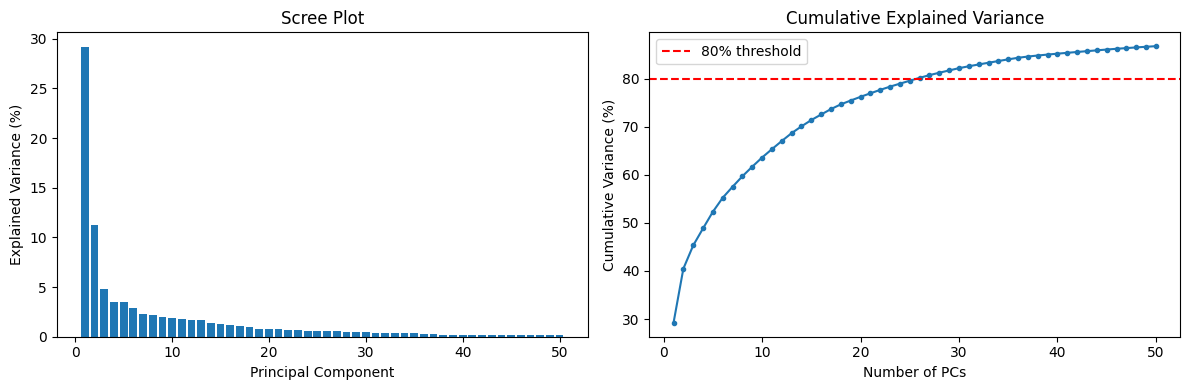

Variance explained by 50 PCs: 86.8%


In [24]:
N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_imputed)

explained = pca.explained_variance_ratio_
cum_var = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, N_COMPONENTS + 1), explained * 100)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot")

axes[1].plot(range(1, N_COMPONENTS + 1), cum_var * 100, marker='o', markersize=3)
axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Variance explained by {N_COMPONENTS} PCs: {cum_var[-1]*100:.1f}%")

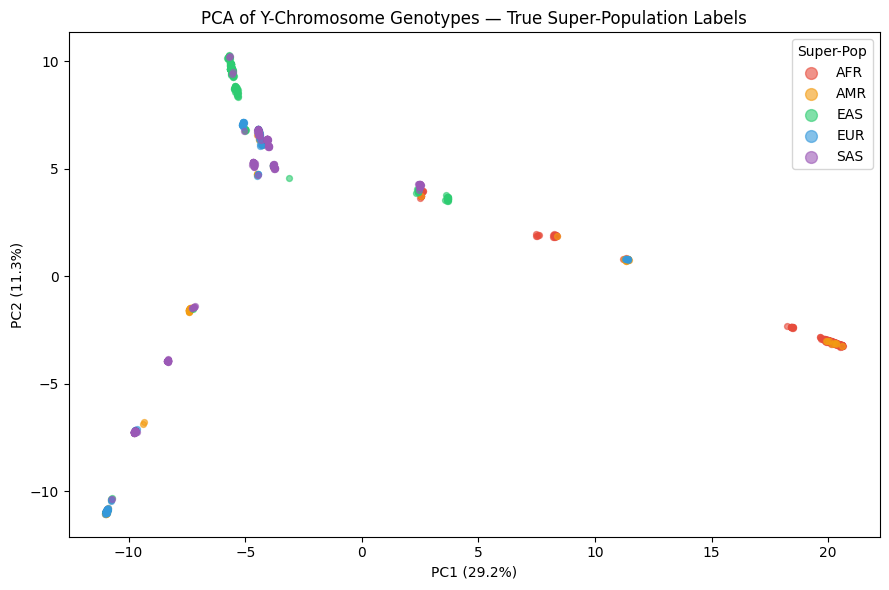

In [25]:
# ── PCA scatter: PC1 vs PC2 coloured by true super-pop ──────────────────────
POP_COLORS = {'AFR': '#E74C3C', 'AMR': '#F39C12', 'EAS': '#2ECC71', 'EUR': '#3498DB', 'SAS': '#9B59B6'}

plt.figure(figsize=(9, 6))
for pop in le.classes_:
    mask = y_str == pop
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=POP_COLORS[pop], label=pop, alpha=0.6, s=18)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}%)")
plt.title("PCA of Y-Chromosome Genotypes — True Super-Population Labels")
plt.legend(title="Super-Pop", markerscale=2)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_pca_true_labels.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Supervised Classification

**Setup:** Stratified 80/20 train-test split. PCA features (50 PCs) as input.  
All models are also evaluated with 5-fold cross-validation on the training set.

In [26]:
X_train, X_test, y_train, y_test, y_train_str, y_test_str = train_test_split(
    X_pca, y, y_str, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

# class counts in train
unique, counts = np.unique(y_train_str, return_counts=True)
print("Train class distribution:", dict(zip(unique, counts)))

Train: 986 samples | Test: 247 samples
Train class distribution: {'AFR': np.int64(255), 'AMR': np.int64(136), 'EAS': np.int64(195), 'EUR': np.int64(192), 'SAS': np.int64(208)}


In [27]:
# ── Define classifiers ───────────────────────────────────────────────────────
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, solver='lbfgs',
        C=1.0, random_state=RANDOM_STATE
    ),
    "SVM (RBF)": SVC(
        kernel='rbf', C=10, gamma='scale',
        decision_function_shape='ovo', random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, random_state=RANDOM_STATE
    ),
    "KNN (k=5)": KNeighborsClassifier(
        n_neighbors=5, metric='euclidean', n_jobs=-1
    ),
}

print(f"Classifiers to train: {list(classifiers.keys())}")

Classifiers to train: ['Logistic Regression', 'SVM (RBF)', 'Random Forest', 'Decision Tree', 'KNN (k=5)']


In [28]:
# ── Train, evaluate, collect results ────────────────────────────────────────
results = []
trained_models = {}

for name, clf in classifiers.items():
    print(f"\n{'─'*50}")
    print(f"Training: {name}")
    
    clf.fit(X_train, y_train)
    trained_models[name] = clf
    
    # test set performance
    y_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    # 5-fold CV on training set
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    
    results.append({
        'Model': name,
        'Test Accuracy': round(test_acc, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
    })
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


──────────────────────────────────────────────────
Training: Logistic Regression
  Test Accuracy : 0.8623
  CV Accuracy   : 0.8266 ± 0.0270
              precision    recall  f1-score   support

         AFR       0.97      0.95      0.96        64
         AMR       0.83      0.44      0.58        34
         EAS       0.96      1.00      0.98        49
         EUR       0.65      0.83      0.73        48
         SAS       0.91      0.92      0.91        52

    accuracy                           0.86       247
   macro avg       0.86      0.83      0.83       247
weighted avg       0.87      0.86      0.86       247


──────────────────────────────────────────────────
Training: SVM (RBF)
  Test Accuracy : 0.8583
  CV Accuracy   : 0.8357 ± 0.0197
              precision    recall  f1-score   support

         AFR       0.97      0.95      0.96        64
         AMR       0.84      0.47      0.60        34
         EAS       0.96      0.98      0.97        49
         EUR       0.6

In [29]:
# ── Summary comparison table ─────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))


=== Model Comparison ===
              Model  Test Accuracy  CV Mean  CV Std
Logistic Regression         0.8623   0.8266  0.0270
          SVM (RBF)         0.8583   0.8357  0.0197
      Random Forest         0.8583   0.8347  0.0175
          KNN (k=5)         0.8300   0.8215  0.0151
      Decision Tree         0.8097   0.7982  0.0286


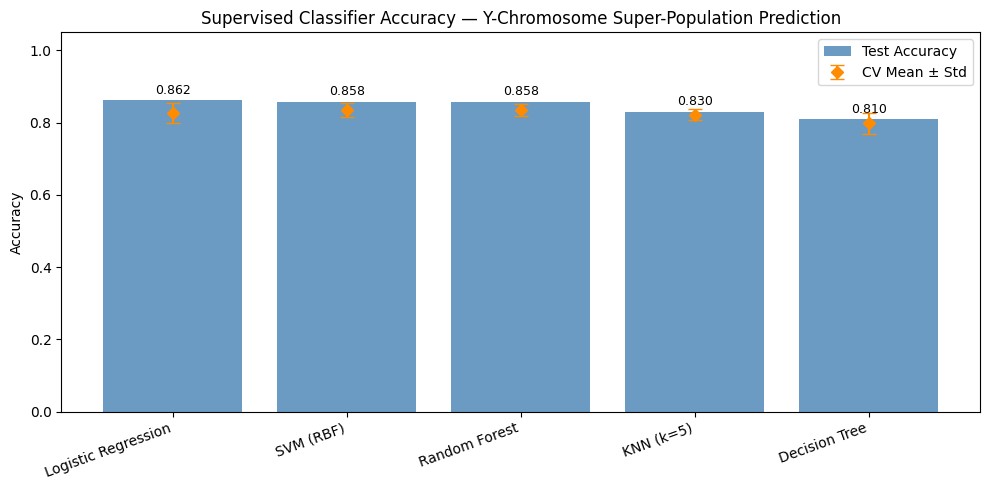

In [30]:
# ── Bar chart: model accuracy comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
bars = ax.bar(x, results_df['Test Accuracy'], color='steelblue', alpha=0.8, label='Test Accuracy')
ax.errorbar(x, results_df['CV Mean'], yerr=results_df['CV Std'],
            fmt='D', color='darkorange', capsize=5, label='CV Mean ± Std', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Supervised Classifier Accuracy — Y-Chromosome Super-Population Prediction')
ax.set_ylim(0, 1.05)
ax.legend()
for bar, val in zip(bars, results_df['Test Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_classifier_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

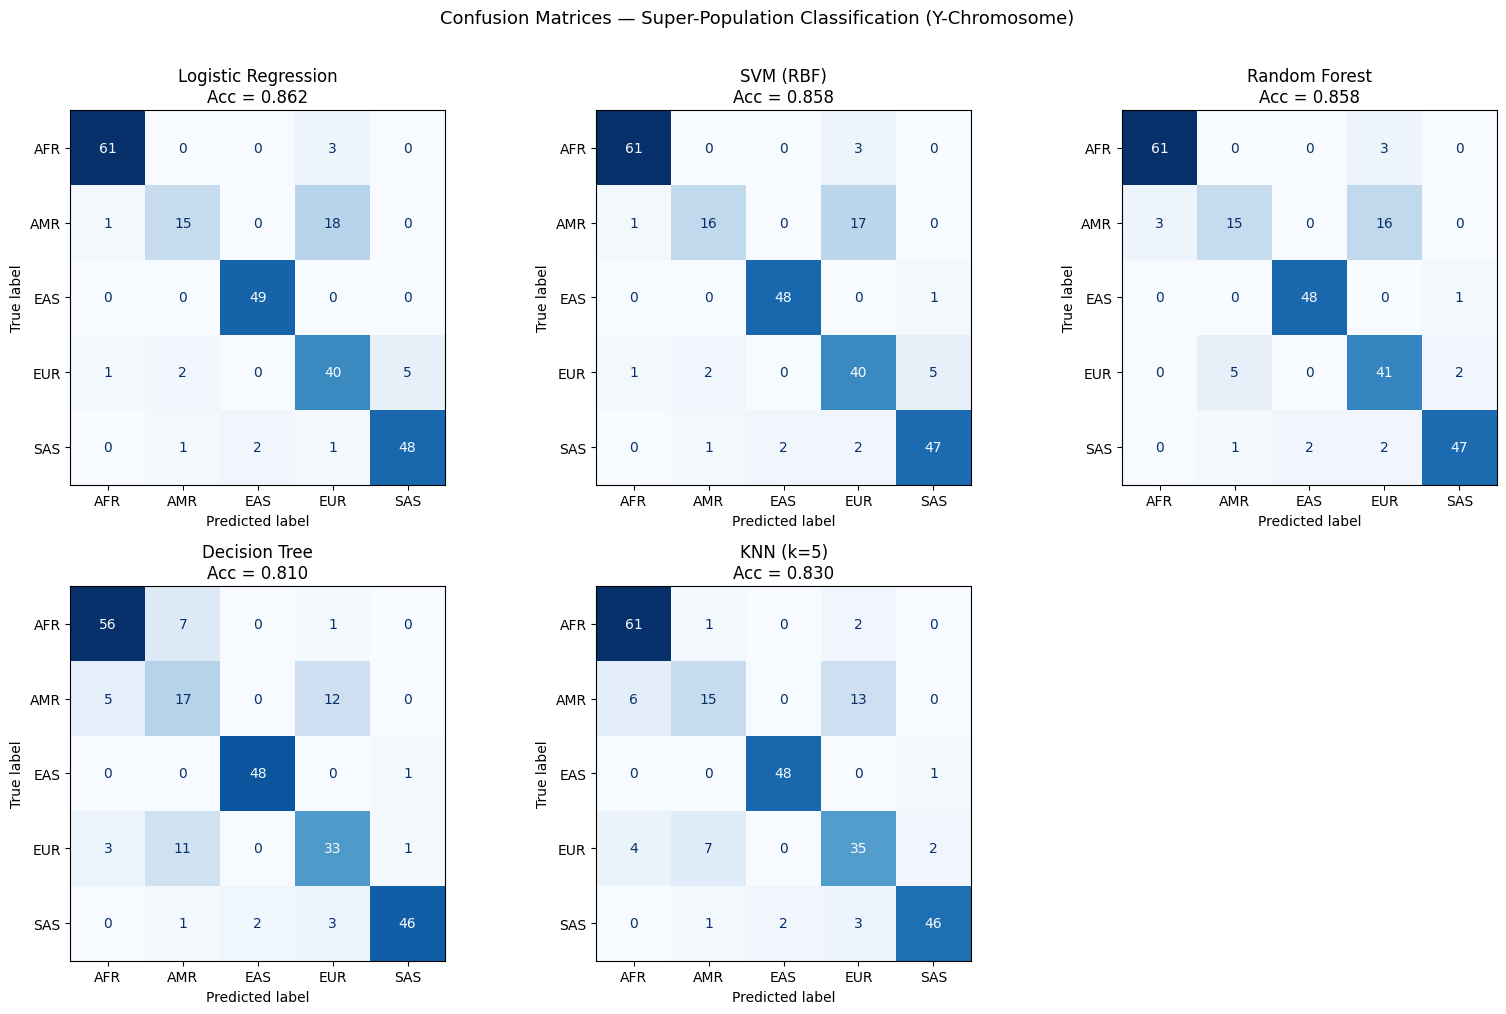

In [31]:
# ── Confusion matrices for all classifiers ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, clf) in enumerate(trained_models.items()):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f"{name}\nAcc = {acc:.3f}")

# hide the unused 6th subplot
axes[-1].set_visible(False)

plt.suptitle("Confusion Matrices — Super-Population Classification (Y-Chromosome)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Unsupervised: K-Means Clustering (k=5)

k=5 matches the 5 super-population classes. We compare discovered clusters to true labels using **Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)**.

In [32]:
# ── Fit K-Means on full PCA-reduced data ─────────────────────────────────────
kmeans = KMeans(n_clusters=5, n_init=20, max_iter=500, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_pca)

ari = adjusted_rand_score(y, cluster_labels)
nmi = normalized_mutual_info_score(y, cluster_labels)

print(f"K-Means (k=5) Results")
print(f"  Adjusted Rand Index (ARI) : {ari:.4f}  (1.0 = perfect, 0 = random)")
print(f"  Normalized Mutual Info    : {nmi:.4f}  (1.0 = perfect, 0 = no shared info)")
print(f"  Inertia                   : {kmeans.inertia_:.2f}")

K-Means (k=5) Results
  Adjusted Rand Index (ARI) : 0.4637  (1.0 = perfect, 0 = random)
  Normalized Mutual Info    : 0.4922  (1.0 = perfect, 0 = no shared info)
  Inertia                   : 229165.05


In [33]:
# ── Cluster composition: which true pops ended up in each cluster? ───────────
composition_df = pd.DataFrame({'cluster': cluster_labels, 'true_pop': y_str})
comp_table = composition_df.groupby(['cluster', 'true_pop']).size().unstack(fill_value=0)
comp_pct = comp_table.div(comp_table.sum(axis=1), axis=0).round(3)

print("\nCluster composition (counts):")
print(comp_table)
print("\nCluster composition (proportions):")
print(comp_pct)


Cluster composition (counts):
true_pop  AFR  AMR  EAS  EUR  SAS
cluster                          
0          21   29   34   71  148
1          12  110    3  128   36
2         286   30    0    6    0
3           0    0  207   23    5
4           0    1    0   12   71

Cluster composition (proportions):
true_pop    AFR    AMR    EAS    EUR    SAS
cluster                                    
0         0.069  0.096  0.112  0.234  0.488
1         0.042  0.381  0.010  0.443  0.125
2         0.888  0.093  0.000  0.019  0.000
3         0.000  0.000  0.881  0.098  0.021
4         0.000  0.012  0.000  0.143  0.845


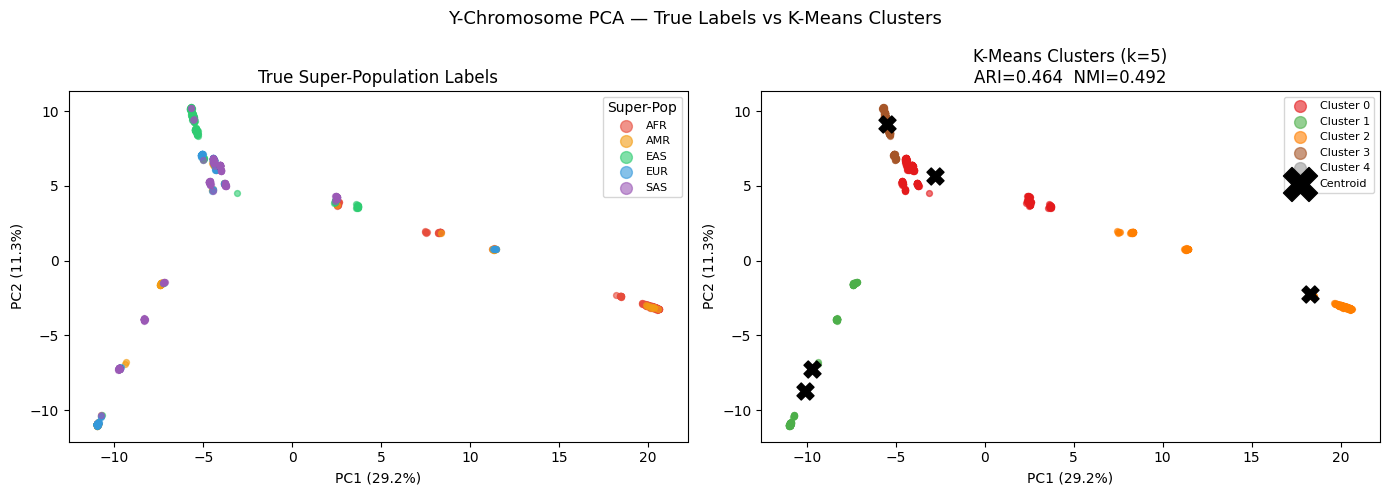

In [34]:
# ── Side-by-side PCA scatter: True labels vs K-Means clusters ────────────────
CLUSTER_COLORS = plt.cm.Set1(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: true super-pop labels
for pop in le.classes_:
    mask = y_str == pop
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=POP_COLORS[pop], label=pop, alpha=0.6, s=18)
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[0].set_title("True Super-Population Labels")
axes[0].legend(title="Super-Pop", markerscale=2, fontsize=8)

# Right: K-Means clusters
for k in range(5):
    mask = cluster_labels == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=CLUSTER_COLORS[k], label=f"Cluster {k}", alpha=0.6, s=18)
# plot centroids projected onto PC1/PC2
centroids_2d = kmeans.cluster_centers_[:, :2]
axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=150, zorder=10, label='Centroid')
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title(f"K-Means Clusters (k=5)\nARI={ari:.3f}  NMI={nmi:.3f}")
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle("Y-Chromosome PCA — True Labels vs K-Means Clusters", fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_kmeans_vs_true.png", dpi=150, bbox_inches='tight')
plt.show()

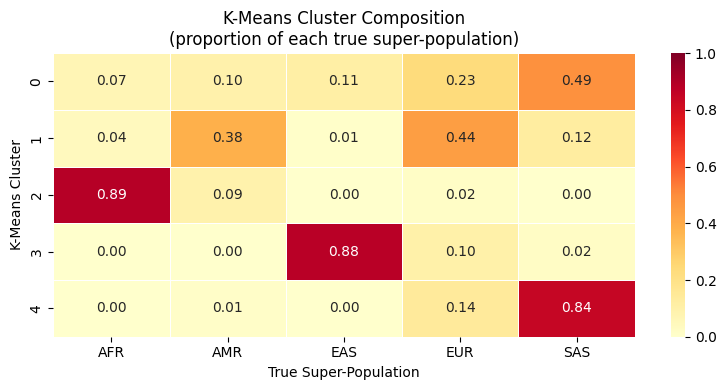

In [35]:
# ── Heatmap: cluster composition proportions ──────────────────────────────────
plt.figure(figsize=(8, 4))
sns.heatmap(comp_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1)
plt.title("K-Means Cluster Composition\n(proportion of each true super-population)")
plt.xlabel("True Super-Population")
plt.ylabel("K-Means Cluster")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_kmeans_composition_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

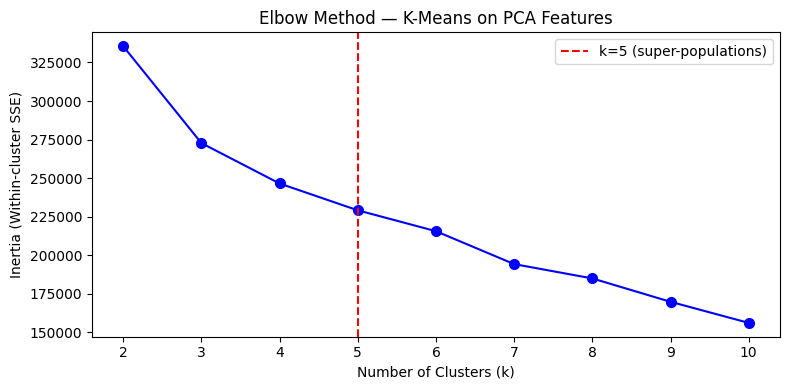

In [36]:
# ── Elbow method: inertia vs k (to validate k=5) ─────────────────────────────
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'bo-', markersize=7)
plt.axvline(x=5, color='red', linestyle='--', label='k=5 (super-populations)')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.title("Elbow Method — K-Means on PCA Features")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/exp1_kmeans_elbow.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Final Summary

In [37]:
print("=" * 60)
print("EXPERIMENT 1 — FINAL SUMMARY")
print("=" * 60)
print(f"\nDataset: {X_pca.shape[0]} male samples | {X_imputed.shape[1]:,} variants | 50 PCs")
print(f"Target : 5 super-populations — {list(le.classes_)}")

print("\n── SUPERVISED (Test Accuracy) ──")
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} {row['Test Accuracy']:.4f}  "
          f"(CV: {row['CV Mean']:.4f} ± {row['CV Std']:.4f})")

best = results_df.iloc[0]
print(f"\n  Best model: {best['Model']} (Test Acc = {best['Test Accuracy']:.4f})")

print("\n── UNSUPERVISED (K-Means, k=5) ──")
print(f"  ARI : {ari:.4f}")
print(f"  NMI : {nmi:.4f}")
print("\nAll plots saved to Output/ directory.")
print("=" * 60)

EXPERIMENT 1 — FINAL SUMMARY

Dataset: 1233 male samples | 60,789 variants | 50 PCs
Target : 5 super-populations — ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']

── SUPERVISED (Test Accuracy) ──
  Logistic Regression    0.8623  (CV: 0.8266 ± 0.0270)
  SVM (RBF)              0.8583  (CV: 0.8357 ± 0.0197)
  Random Forest          0.8583  (CV: 0.8347 ± 0.0175)
  KNN (k=5)              0.8300  (CV: 0.8215 ± 0.0151)
  Decision Tree          0.8097  (CV: 0.7982 ± 0.0286)

  Best model: Logistic Regression (Test Acc = 0.8623)

── UNSUPERVISED (K-Means, k=5) ──
  ARI : 0.4637
  NMI : 0.4922

All plots saved to Output/ directory.
